# Imports #

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import math 

# Rational Bezier Function #

In [3]:
def b_polynomial(t,P):
    n = len(P)-1
    num_x = np.zeros([n+1,len(t)])
    num_y = np.zeros([n+1,len(t)])
    denom = np.zeros([n+1, len(t)])

    for i in range(n+1):
        w = P[i][0]
        x = P[i][1]
        y = P[i][2]
        comb = math.comb(n,i)
        B_i = comb*(t**i)*(1-t)**(n-i)
        num_x[i,:]= B_i*w*x
        num_y[i,:]=B_i*w*y
        denom[i,:]=B_i*w
    B_x = np.sum(num_x,axis=0)
    B_y = np.sum(num_y,axis=0)
    B_denom = np.sum(denom, axis=0)
    return B_x/B_denom, B_y/B_denom 

# Function to create ECG signal #

In [ ]:
def ECG_wave(signal_type):
    #Checking signal type 
    if signal_type == 'Normal':
       points_preP = [[1,0,0],[1,0.5,0],[1,1,0],[1,1.5,0],[1,2,0],[1,2.5,0],[1,3,0]]
       points_P = [[10,3.5,0],[1,4,0.3],[2,5,0.9],[20,6,1.3],[2,7,0.8],[1.5,7.3,0.5],[10,8,0]]
       points_preQRS = [[1,8.25,0],[1,8.5,0],[1,8.75,0],[1,9,0],[1,9.25,0],[1,9.5,0],[1,10,0]]
       points_QRS = [[10,10.3,0],[500,11.1,-1.5],[10,11.25,0],[1000,12,11],[10,12.65,0],[500,12.85,-3.3],[10,13.7,0]]
       points_preT = [[1,14,0],[1,14.5,0],[1,14.75,0],[1,15,0],[1,15.5,0],[1,16,0],[1,16.5,0]]
       points_T = [[10,17,0],[1,18,1],[2,19,1.9],[20,19.6,2.1],[2,21,0.55],[10,21.4,0]]
       points_postT = [[1,21.5,0],[1,22,0],[1,22.5,0],[1,23,0],[1,23.5,0],[1,24,0]]
       
       prePx,prePy = b_polynomial(t,points_preP)
       Px,Py = b_polynomial(t,points_P)
       preQRSx,preQRSy = b_polynomial(t,points_preQRS)
       QRSx,QRSy = b_polynomial(t, points_QRS)
       preTx, preTy = b_polynomial(t, points_preT)
       Tx,Ty = b_polynomial(t, points_T)
       postTx, postTy = b_polynomial(t, points_postT)
       
       x = np.concatenate((prePx, Px, preQRSx,QRSx, preTx, Tx, postTx),axis=0)
       y = np.concatenate((prePy,Py,preQRSy, QRSy, preTy, Ty, postTy),axis=0)
       
 
    elif signal_type == "Ventricular pacing":
        points_preP = [[1,0,0],[1,1,0],[1,2,0],[1,2.5,0]]
        points_P = [[10,2.9,0],[5,3.6,0.7],[15,4.15,0.9],[15,4.25,0.9],[5,4.7,0.7],[10,5.4,0]]
        points_prePacemaker = [[1,5.5,0],[1,6,0],[1,7,0],[1,8,0]]
        points_Pacemaker = [[1,8.3,0],[10,8.4,14],[1,8.5,0]]
        points_QRS = [[2,9,-0.8],[1,9.5,-3.1],[5,9.9,-7.1],[5,10.2,-7.6],[1,10.5,-11.5],[10,11.05,-16.8],[1,11.5,-14.6],[1,12,-10.5],[1,12.5,-6.4],[1,13,-3],[10,13.6,0]]
        points_T = [[10,13.61,0],[1,13.8,0.4],[1,14,0.75],[1,14.5,1.8],[1,15,2.75],[1,15.5,3.6],[1,16,4.15],[5,16.5,4.75],[5,17,5.4],[15,17.45,5.7],[5,18,5.3],[5,18.5,4.4],[1,19,3],[1,19.5,1.6],[1,20,0.5],[1,20.4,0]]
        points_postT = [[1,21,0],[1,22,0],[1,23,0],[1,24,0],[1,25,0]]

        prePx,prePy = b_polynomial(t,points_preP)
        Px,Py = b_polynomial(t,points_P)
        prePacemakerx, prePacemakery = b_polynomial(t,points_prePacemaker)
        Pacemakerx, Pacemakery = b_polynomial(t,points_Pacemaker)
        QRSx,QRSy = b_polynomial(t, points_QRS)
        Tx,Ty = b_polynomial(t, points_T)
        postTx, postTy = b_polynomial(t, points_postT)

        x = np.concatenate((prePx, Px, prePacemakerx, Pacemakerx, QRSx, Tx, postTx),axis=0)
        y = np.concatenate((prePy,Py,prePacemakery, Pacemakery, QRSy, Ty, postTy),axis=0)

    #Need to add signal without capture (i.e. if output setting too low)

    return x,y


# Patient heart rate function #
Used to get the spacing between pulses to achieve a certain patient heart rate

In [5]:
def heart_rate(patient_HR):
    '''
    Calculates the gap between beats based on patient heart rate in bpm
    Note: assumes all heart beats are exactly the same (based on standard heartbeat defined in ECG_wave function)
    only gives give that results in approximately patient_HR
    '''
    gap = (1500)*(0.04)/patient_HR - 0.4007574025940901 - 0.39924259740590995
    return gap



# Stitch beats function #
Puts heart beats in sequential order and determines whether next beat should be paced based on sensitivity and rate settings of pacemaker

In [339]:
def stitch_beats_new(ecg_func, gap, regularity, sensitivity,rate, output, asynchronous):
    ''' Function to stitch together multiple ECG beats into a continuous signal.
    Parameters:
    ecg_func: function that generates ECG waveform for a given signal type 
    gap: base gap between beats
    regularity: 'Regular' or 'Irregular' spacing between beats
    sensitivity: sensitivity setting of pacemaker in mV
    rate: programmed rate of pacemaker in bpm 
    output: output setting of pacemaker in mA
    asynchronous: boolean indicating if pacemaker is in asynchronous mode

    Returns:
    x: concatenated x values of ECG waveform for 10 iterations
    y: concatenated y values of ECG waveform for 10 iterations
    '''
    #Need to add async option 
    #Maybe can add something so points in ECG wave function randomised 
    beat_list = ['Normal']
    offset = 0 
    time_since_sensed = 0 
    max_time_since_sensed = (1500*0.04)/rate
    capture_threshold = 1.5 
    if asynchronous:
        regularity = 'Regular' #Override regularity if asynchronous mode is on

    for i in range(10):
        #Will have to edit function so it checks sensitivity value at each iteration
        x_temp, y_temp = ecg_func(beat_list[i])
        
        #Make random scaling factor in x and y for each iteration so the pulses aren't exactly the same
        #Only apply random scaling factor in x if regularity is 'Irregular', otherwise keep it constant
        if regularity == 'Irregular':
            scaling_factor_x = (0.8+(np.random.random()*0.6-0.3))/(np.max(x_temp)-np.min(x_temp))
        else:
            scaling_factor_x = 0.8/(np.max(x_temp)-np.min(x_temp))
        scaling_factor_y = (1.0+(np.random.random()*0.6-0.3))/(np.max(y_temp)-np.min(y_temp))

        if offset == 0: #First beat in beat_list 
            R_location = 0
            #Apply scaling factors:
            x_temp = x_temp*scaling_factor_x 
            y_temp = y_temp*scaling_factor_y
            x = x_temp
            y = y_temp

            #Increase time since last sensed event if beat is not sensed
            if np.max(y_temp) < sensitivity:
                time_since_sensed += np.max(x_temp)
                #If time since last sensed event exceeds max time, append a paced beat
                if time_since_sensed >= max_time_since_sensed:
                    if output >= capture_threshold: #Check if output setting is sufficient for capture
                        beat_list.append("Ventricular pacing")
                    elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                    else:
                        beat_list.append("Normal") #If no capture, just append normal beat
                    time_since_sensed = 0 #Reset time since sensed after pacing
                elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                    beat_list.append("Ventricular pacing")
                else: 
                    beat_list.append('Normal')
    
            
            #If beat is sensed, then determine location of R wave
            else:
                #Determine R wave location
                R_location = x_temp[np.argmax(y_temp)]
                 #Append normal heart beat - need to determine distance between R waves of subsequent beats to choose whether to pace
                if asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                    beat_list.append("Ventricular pacing")
                else:
                    beat_list.append('Normal')
                time_since_sensed = 0

            #Apply offset for next beat
            offset = np.max(x_temp)

            
           

        else: #Second beat onwards
            #Apply scaling factors:
            x_temp = x_temp*scaling_factor_x
            y_temp = y_temp*scaling_factor_y

            #Determine gap based on regularity of heart rhythm
            if regularity == 'Irregular':
                gap += np.random.random()*gap
            x_temp_shifted = x_temp + offset + gap

            x = np.concatenate((x, x_temp_shifted), axis=0)
            y = np.concatenate((y, y_temp), axis=0)
            offset = np.max(x_temp_shifted)

            if np.max(y_temp) < sensitivity: #Increase time since last sensed event if beat is not sensed
                time_since_sensed += np.max(x_temp) + gap
                #If time since last sensed event exceeds max time, append a paced beat
                if time_since_sensed >= max_time_since_sensed:
                    if output >= capture_threshold: #Check if output setting is sufficient for capture
                        beat_list.append("Ventricular pacing")
                    else:
                        beat_list.append("Normal") #If no capture, just append normal beat
                    time_since_sensed = 0 #Reset time since sensed after pacing
                elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                else: 
                    beat_list.append('Normal')

            else: #If beat is sensed, then determine location of R wave and calculate measured rate
                RR_dist = x_temp_shifted[np.argmax(y_temp)]-R_location
                #Convert distance between R waves to bpm
                measured_rate = 1500*0.04/RR_dist
                
                #Update R_location for next iteration
                if beat_list[i] == "Ventricular pacing":
                    R_location = x_temp_shifted[np.argmin(y_temp)] #R wave is at minimum for paced beat
                else:
                    R_location = x_temp_shifted[np.argmax(y_temp)] #R wave is at maximum for normal beat
                    
                if measured_rate < rate: #If the measured rate is less than the programmed rate, append a paced beat and then a normal beat
                    if output >= capture_threshold: #Check if output setting is sufficient for capture
                        beat_list.append("Ventricular pacing")
                    elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                    else:
                        beat_list.append("Normal") #If no capture, just append normal beat
                    if not asynchronous:
                        beat_list.append("Normal") #I'm adding a normal beat after a paced beat, because I'm assuming the paced beat should have the correct heart rate
                
                elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                else: #Otherwise append a normal beat
                    beat_list.append('Normal')


    return x, y


# Plotting #

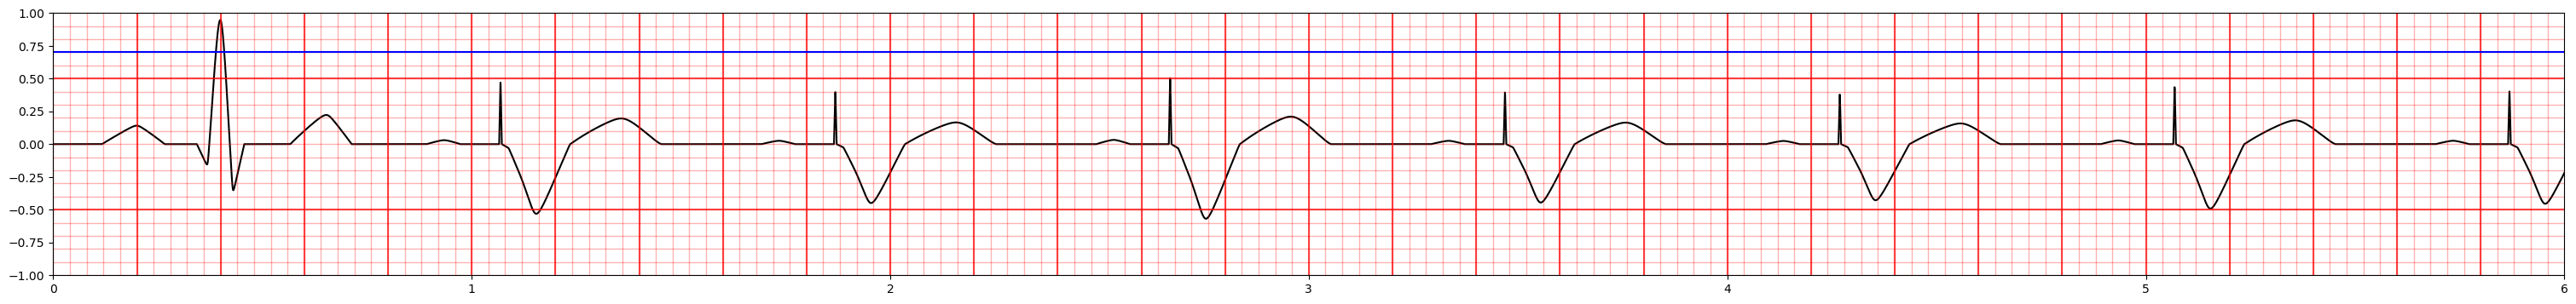

In [344]:
t = np.linspace(0,1,101)
patient_HR = 75
gap = heart_rate(patient_HR)
sensitivity = 0.7
x_ecg, y_ecg = stitch_beats_new(ECG_wave, gap, regularity='Irregular', sensitivity=sensitivity, rate=70, output=1.5, asynchronous=True)

fig, ax = plt.subplots(figsize=(38, 4))
ax.plot(x_ecg, y_ecg, color='black')
ax.set_xlim(0, 6)
ax.set_ylim(-1, 1)

# compute line positions 
big_lines_v = np.arange(0, 6, 0.2)
small_lines_v = np.arange(0, 6, 0.04)
big_lines_h = np.arange(-1.5, 1.5, 1)
small_lines_h = np.arange(-1.5, 1.5, 0.1)

ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()

# draw vertical lines (from ymin to ymax) in a single call each
ax.vlines(big_lines_v, ymin, ymax, colors='red', alpha=0.7, linewidth=1.5)
ax.vlines(small_lines_v, ymin, ymax, colors='red', alpha=0.3, linewidth=1)

# draw horizontal lines (from xmin to xmax)
ax.hlines(big_lines_h, xmin, xmax, colors='red', alpha=0.7, linewidth=1.5)
ax.hlines(small_lines_h, xmin, xmax, colors='red', alpha=0.3, linewidth=1)

#Line to indicate sensitivity setting
ax.hlines(sensitivity, xmin, xmax, colors='blue', alpha=1, linewidth=1.5)